Yayy!!

# Introduction

A group of UBC computer science students, named The Pacific Laboratory for Artificial Intelligence (PLAI), are conducting research on player actions in their own MineCraft server, PLAIcraft. This is being done with hopes of developing an advanced AI tool, also known as embodied AI, to implement in the video game. Additionally, supporting the server requires adequate information about the amount and type of players for recruitment efforts. As such, data on players and their gameplay is being collected through this MineCraft server.  


## Data Description (subtitle tbd)

In [1]:
library(tidyverse)

players <- read_csv("https://raw.githubusercontent.com/chrispy-tacos/dsci-100-project/refs/heads/main/players.csv")
sessions <- read_csv("https://raw.githubusercontent.com/chrispy-tacos/dsci-100-project/refs/heads/main/sessions.csv")

sessions_compressed <- sessions |>
    select(hashedEmail) |>
    group_by(hashedEmail) |>
    summarize(session_count = n())

combined_data <- players |>
    inner_join(sessions_compressed)

combined_data

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimite

experience,subscribe,hashedEmail,played_hours,name,gender,Age,session_count
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<int>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9,27
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17,3
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17,1
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21,1
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21,1
Amateur,FALSE,1d2371d8a35c8831034b25bda8764539ab7db0f63938696917c447128a2540dd,0.0,Emerson,Male,21,1
Amateur,TRUE,8b71f4d66a38389b7528bb38ba6eb71157733df7d1740371852a797ae97d82d1,0.1,Natalie,Male,47,1
Veteran,TRUE,7a4686586d290c67179275c7c3dfb4ea02f4d317d9ee0e2cee98baa27877a875,1.6,Lane,Female,23,3
Beginner,TRUE,4bed6f49b672974f706aa7f020b4f29020326bf594520593557cd381a51559b8,1.5,Sarah,Female,25,1


## Loading another library 

In [8]:
library(tidymodels)

── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.1.2
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.0.1
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filter()   masks stats::filter()
✖ recipes::fixed()  masks stringr::fixed()
✖ dplyr::lag()      masks stats::lag()
✖ yardstick::spec() masks readr::spec()
✖ recipes::step()   masks stats::step()
• Search for functions across packages at https://www.tidymodels.org/find/



## Determining the method for data analysis 

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


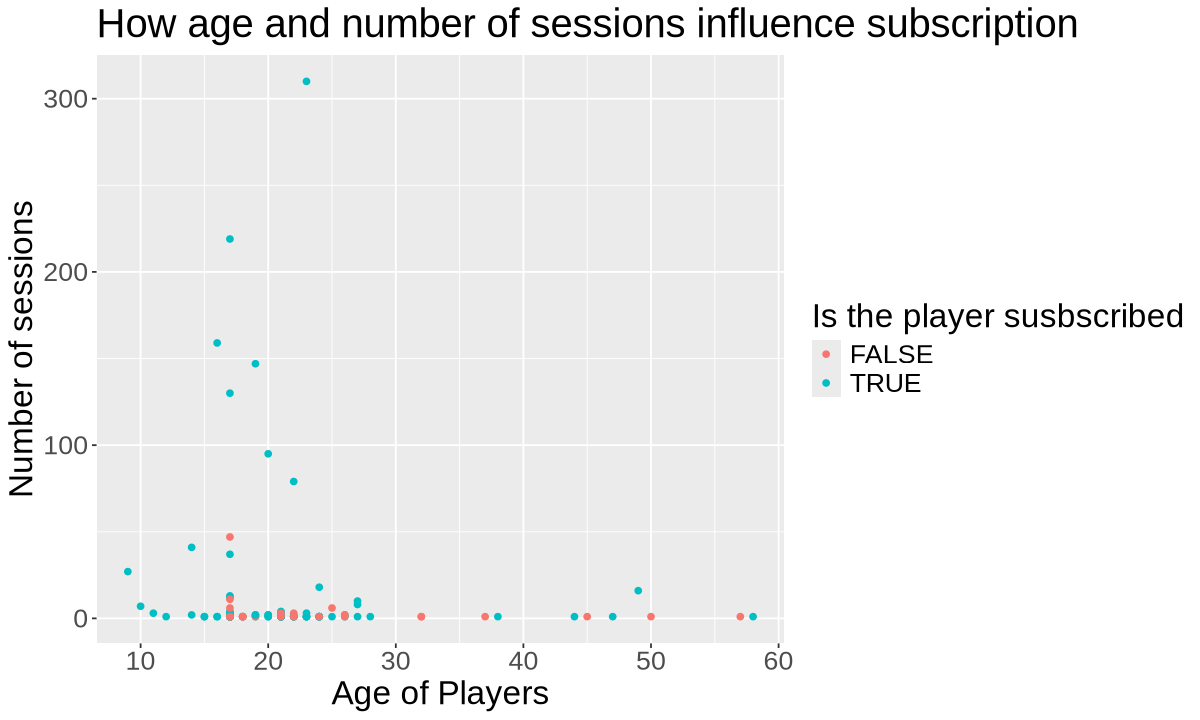

In [9]:
options(repr.plot.width=10, repr.plot.height=6)

plot_of_age_vs_subscription<- ggplot(combined_data, aes(x = Age, y = session_count))+
geom_point(aes(colour = subscribe))+ 
xlab("Age of Players")+ 
ylab("Number of sessions")+ 
ggtitle("How age and number of sessions influence subscription")+
labs(colour= "Is the player susbscribed")+
theme(text = element_text(size = 20))

plot_of_age_vs_subscription

## Renaming the Subscribe observations 

In [38]:
combined_data <- combined_data |>
  mutate(subscribe = factor(subscribe))


## Splitting the data for training and analysis 

In [52]:
minecraft_split<- initial_split(combined_data, prop = 0.75, strata = subscribe)
minecraft_training<- training(minecraft_split) 
minecraft_testing<- testing(minecraft_split)

## Making a recipe

In [53]:
minecraft_vfold<- vfold_cv(minecraft_training, v= 5, strata = subscribe)

minecraft_recipe<- recipe(subscribe ~ Age + session_count, data = minecraft_training)|> 
step_scale(Age, session_count)|> 
step_center(Age, session_count)

minecraft_recipe



── Recipe ──────────────────────────────────────────────────────────────────────



── Inputs 

Number of variables by role

outcome:   1
predictor: 2



── Operations 

• Scaling for: Age and session_count

• Centering for: Age and session_count



## Creating the K-NN classifier 

In [60]:
minecraft_knn_spec<- nearest_neighbor(weight_func = "rectangular", neighbors = tune())|> 
set_engine("kknn") |> 
set_mode("classification")
minecraft_knn_spec

K-Nearest Neighbor Model Specification (classification)

Main Arguments:
  neighbors = tune()
  weight_func = rectangular

Computational engine: kknn 


In [61]:
k_vals<- tibble(neighbors = seq(from = 1, to = 15, by=2))

knn_k_specification_results<- workflow()|> 
add_recipe(minecraft_recipe)|> 
add_model(minecraft_knn_spec)|>
tune_grid(resamples = minecraft_vfold, grid = k_vals)|> 
collect_metrics()


knn_k_specification_results

→ A | error:   Assigned data `orig_rows` must be compatible with existing data.
               ✖ Existing data has 16 rows.
               ✖ Assigned data has 17 rows.
               ℹ Only vectors of size 1 are recycled.
               Caused by error in `vectbl_recycle_rhs_rows()`:
               ! Can't recycle input of size 17 to size 16.

There were issues with some computations   A: x1

There were issues with some computations   A: x1





neighbors,.metric,.estimator,mean,n,std_err,.config
<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
1,accuracy,binary,0.5000000,4,0.02631579,Preprocessor1_Model1
1,roc_auc,binary,0.5160714,4,0.04199277,Preprocessor1_Model1
3,accuracy,binary,0.5526316,4,0.05478068,Preprocessor1_Model2
3,roc_auc,binary,0.5875000,4,0.04435622,Preprocessor1_Model2
5,accuracy,binary,0.6184211,4,0.01315789,Preprocessor1_Model3
5,roc_auc,binary,0.5946429,4,0.05112468,Preprocessor1_Model3
7,accuracy,binary,0.6578947,4,0.04558028,Preprocessor1_Model4
7,roc_auc,binary,0.6142857,4,0.04720054,Preprocessor1_Model4
9,accuracy,binary,0.6842105,4,0.04804584,Preprocessor1_Model5


## Graph of the K values 

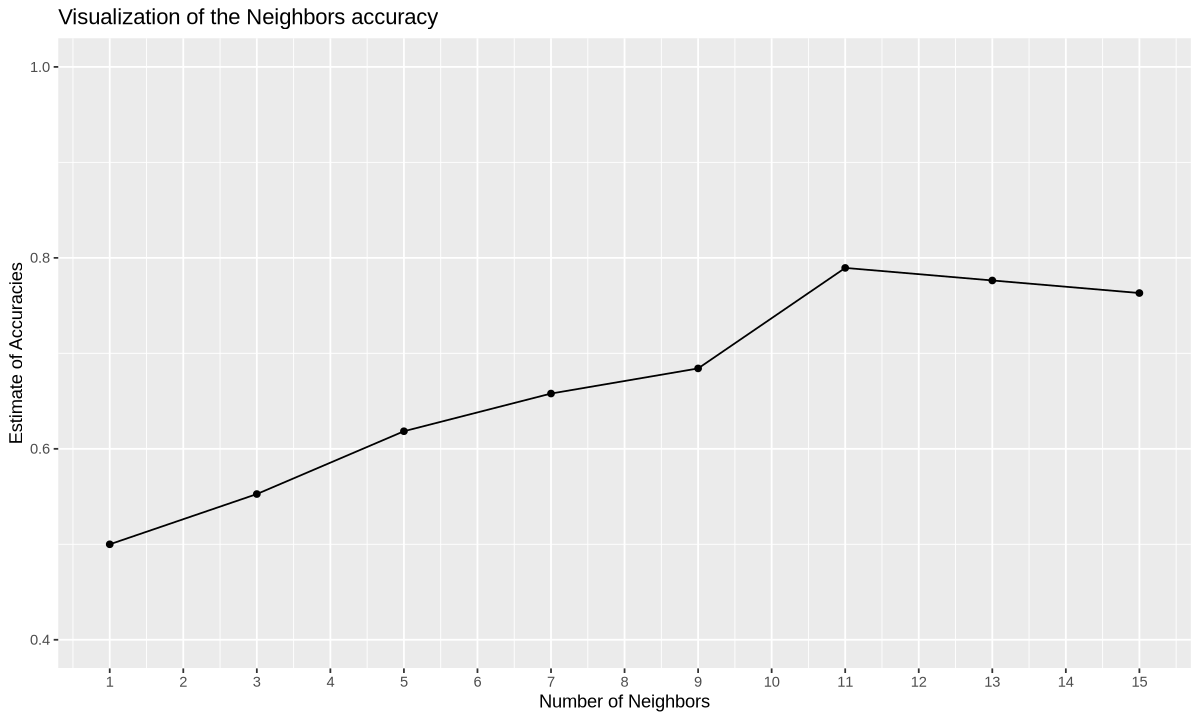

In [62]:
minecraft_accuracy<- knn_k_specification_results|> 
filter(.metric == "accuracy")

plot_of_k_values<- ggplot(minecraft_accuracy, aes(x = neighbors, y = mean))+ 
geom_point()+ 
geom_line()+ 
xlab("Number of Neighbors")+ 
ylab("Estimate of Accuracies")+ 
ggtitle("Visualization of the Neighbors accuracy")+
scale_x_continuous(breaks = seq(0, 20, by = 1)) +  
       scale_y_continuous(limits = c(0.4, 1.0))
plot_of_k_values